DATA LEAKAGE - Train/Test Split
Data leakage happens when the model learns information that would not be available at the time we make real predictions.

We have a dataset containing prices of used BMW cars. We are going to analyze this dataset and build a prediction function that can predict a price by taking mileage and age of the car as input. We will use sklearn train_test_split method to split training and testing dataset

In [ ]:
# Reads the CSV file
# Stores it into a variable called df
# df is now a table in memory

import pandas as pd
df = pd.read_csv("RAW_DATA\\carprices.csv")
df.head(20)

,Mileage,Age(yrs),Sell Price($)
0,69000,6,18000
1,35000,3,34000
2,57000,5,26100
3,22500,2,40000
4,46000,4,31500
5,59000,5,26750
6,52000,5,32000
7,72000,6,19300
8,91000,8,12000
9,67000,6,22000


Columns explained:

Mileage → how much the car has been driven

Age(yrs) → age of the car

Sell Price($) → price we want to predict

In [ ]:
# matplotlib is used to draw graphs
# %matplotlib inline ensures plots appear inside the notebook

import matplotlib.pyplot as plt
%matplotlib inline


Car Mileage Vs Sell Price ($)

Text(0, 0.5, 'Sell Price ($)')

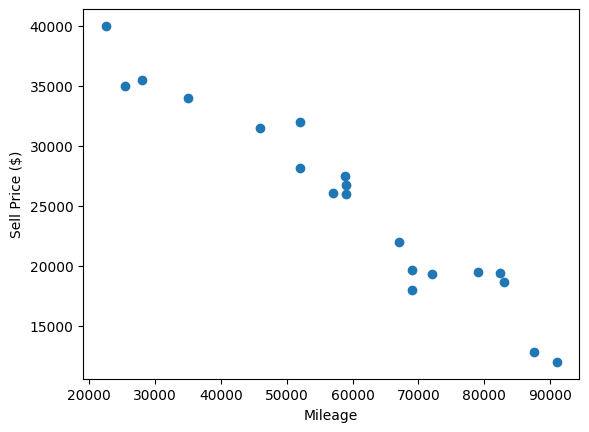

In [101]:

plt.scatter(df['Mileage'],df['Sell Price($)'])
plt.xlabel('Mileage')
plt.ylabel('Sell Price ($)')

What this does:

Creates a scatter plot

X-axis → Mileage

Y-axis → Sell Price

Why this matters:

You can see the relationship

Higher mileage → lower price (roughly linear)

Car Age Vs Sell Price ($)

Text(0, 0.5, 'Sell Price ($)')

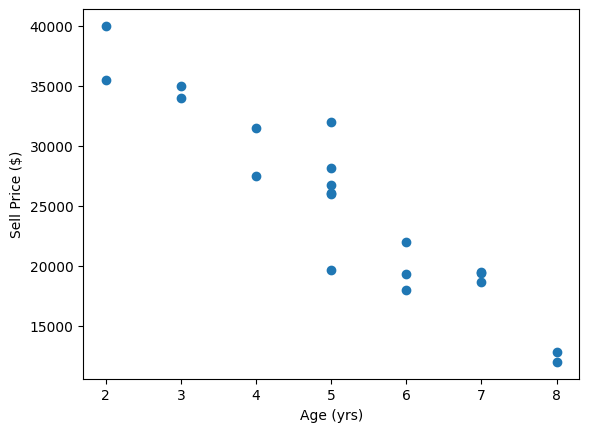

In [102]:
plt.scatter(df['Age(yrs)'],df['Sell Price($)'])
plt.xlabel('Age (yrs)')
plt.ylabel('Sell Price ($)')


Looking at above two scatter plots, using linear regression model makes sense as we can clearly see a linear relationship between our dependant (i.e. Sell Price) and independant variables (i.e. car age and car mileage)

The approach we are going to use here is to split available data in two sets

    1. Training: We will train our model on this dataset
    2.Testing: We will use this subset to make actual predictions using trained model
The reason we don't use same training set for testing is because our model has seen those samples before, using same samples for making predictions might give us wrong impression about accuracy of our model. It is like you ask same questions in exam paper as you taught the students in the class.

In [ ]:
# Prepare feature matrix X using mileage and age as predictors
X = df[['Mileage', 'Age(yrs)']]

📌 Independent Variable (📥 Features: Mileage, Age(yrs))

X = inputs given to the model

These are called features

🧠 Think like this:

Given : Mileage + Age → Predict Price

At prediction time, you only know Mileage & Age — nothing else.

In [ ]:
# Prepare target vector y containing the sell prices
y = df['Sell Price($)']

📌 Dependent Variable (🎯 Target: Sell Price($))

y = what we want to predict

Called the target variable

In [ ]:
# Split data into training and testing sets to avoid data leakage

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

🔹 What happens here?

        70% of data → Training

        30% of data → Testing

🔹 Why split?

If you test on the same data you trained on:

Model cheats

Accuracy looks falsely high

📝 Exam analogy:

Teaching questions ≠ Exam questions

---------------------------------------------------------------------------------

X_train → Mileage & Age used for training

y_train → Prices used for training

X_test → Mileage & Age for testing

y_test → Real prices to compare predictions against

In [ ]:
# Mileage & Age used for training
X_train

,Mileage,Age(yrs)
13,58780,4
18,87600,8
14,82450,7
2,57000,5
7,72000,6
16,28000,2
3,22500,2
1,35000,3
4,46000,4
8,91000,8


In [ ]:
# Mileage & Age for testing
X_test

,Mileage,Age(yrs)
15,25400,3
17,69000,5
5,59000,5
11,79000,7
9,67000,6
19,52000,5


In [ ]:
# Prices used for training
y_train

13    27500
18    12800
14    19400
2     26100
7     19300
16    35500
3     40000
1     34000
4     31500
8     12000
10    18700
0     18000
6     32000
12    26000
Name: Sell Price($), dtype: int64

In [ ]:
# Real prices to compare predictions against
y_test

15    35000
17    19700
5     26750
11    19500
9     22000
19    28200
Name: Sell Price($), dtype: int64

Lets run linear regression model now

In [139]:
from sklearn.linear_model import LinearRegression
clf = LinearRegression()
clf.fit(X_train, y_train)

LinearRegression()

clf.fit(X_train, y_train) :

This is the learning step 🧠

    What happens internally:
      Finds best values for:
        Coefficient for Mileage
        Coefficient for Age
        Intercept
    Learns a formula like:

Price = a*(Mileage) + b*(Age) + c

In [135]:
X_test

,Mileage,Age(yrs)
15,25400,3
17,69000,5
5,59000,5
11,79000,7
9,67000,6
19,52000,5


In [ ]:
# Predicts prices for unseen cars
clf.predict(X_test)

array([38184.95828845, 22208.33145965, 25688.21276077, 17924.10580261,
       22502.13554191, 28124.12967155])

Uses trained model

Predicts prices for unseen cars

Output is an array of predicted prices

In [142]:
y_test

7     19300
10    18700
5     26750
6     32000
3     40000
18    12800
Name: Sell Price($), dtype: int64

Actual prices (ground truth)

📊 Comparing these two tells us:

How close predictions are to reality

In [144]:
clf.score(X_test, y_test)

0.921242248377633

📌This gives R² score

🔹 What does 0.92 mean?

    Model explains 92% of price variation
    Very good for such a small dataset

🔹Score interpretation:

        1.0 → perfect

        0.0 → useless

        < 0 → worse than guessing


random_state argument

In [138]:

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=10)
X_test

,Mileage,Age(yrs)
7,72000,6
10,83000,7
5,59000,5
6,52000,5
3,22500,2
18,87600,8


🔹 Why random_state?

    Ensures same split every time

    Without it:

        Each run gives different training/testing sets

        Different scores

🧪 For learning & debugging → always set random_state